In [482]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [483]:
df= pd.read_csv("diabetes.csv")

In [484]:
df.shape

(768, 9)

In [485]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

In [486]:
df.sample(9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
418,1,83.00,68.00,NaN,NaN,18.20,0.62,27,0
292,2,128.00,78.00,37.00,182.00,43.30,1.22,31,1
453,2,119.00,NaN,NaN,NaN,19.60,0.83,72,0
28,13,145.00,82.00,19.00,110.00,22.20,0.24,57,0
384,1,125.00,70.00,24.00,110.00,24.30,0.22,25,0
222,7,119.00,NaN,NaN,NaN,25.20,0.21,37,0
388,5,144.00,82.00,26.00,285.00,32.00,0.45,58,1
765,5,121.00,72.00,23.00,112.00,26.20,0.24,30,0
693,7,129.00,68.00,49.00,125.00,38.50,0.44,43,1


In [487]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [488]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [489]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
209,7,184.00,84.00,33.00,NaN,35.50,0.35,41,1
616,6,117.00,96.00,NaN,NaN,28.70,0.16,30,0
230,4,142.00,86.00,NaN,NaN,44.00,0.65,22,1
307,0,137.00,68.00,14.00,148.00,24.80,0.14,21,0
412,1,143.00,84.00,23.00,310.00,42.40,1.08,22,0


In [490]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [491]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,763.00,733.00,541.00,394.00,757.00,768.00,768.00,768.00
mean,3.85,121.69,72.41,29.15,155.55,32.46,0.47,33.24,0.35
std,3.37,30.54,12.38,10.48,118.78,6.92,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.00,64.00,22.00,76.25,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,141.00,80.00,36.00,190.00,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


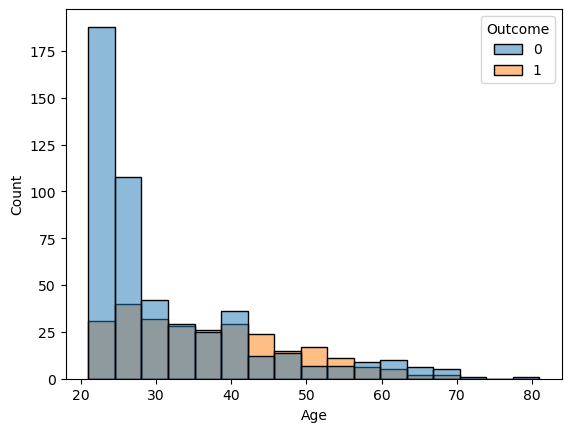

In [492]:
sns.histplot(data=df,x="Age",hue="Outcome")
plt.show()

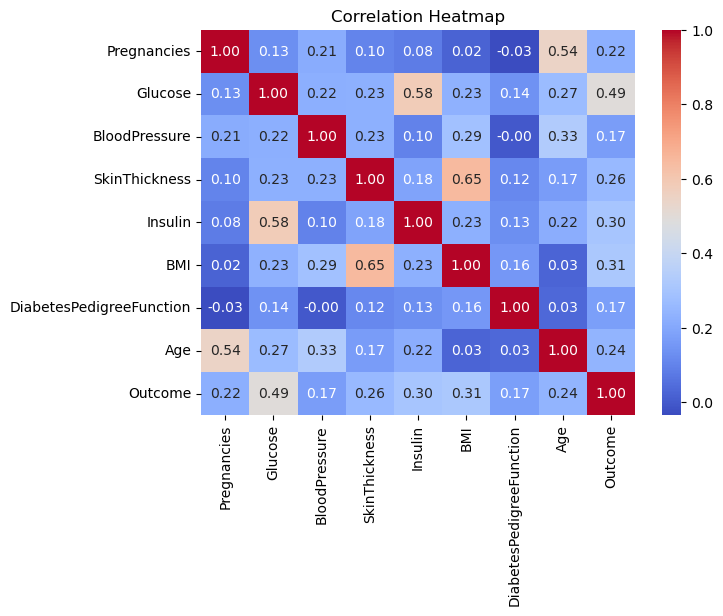

In [493]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

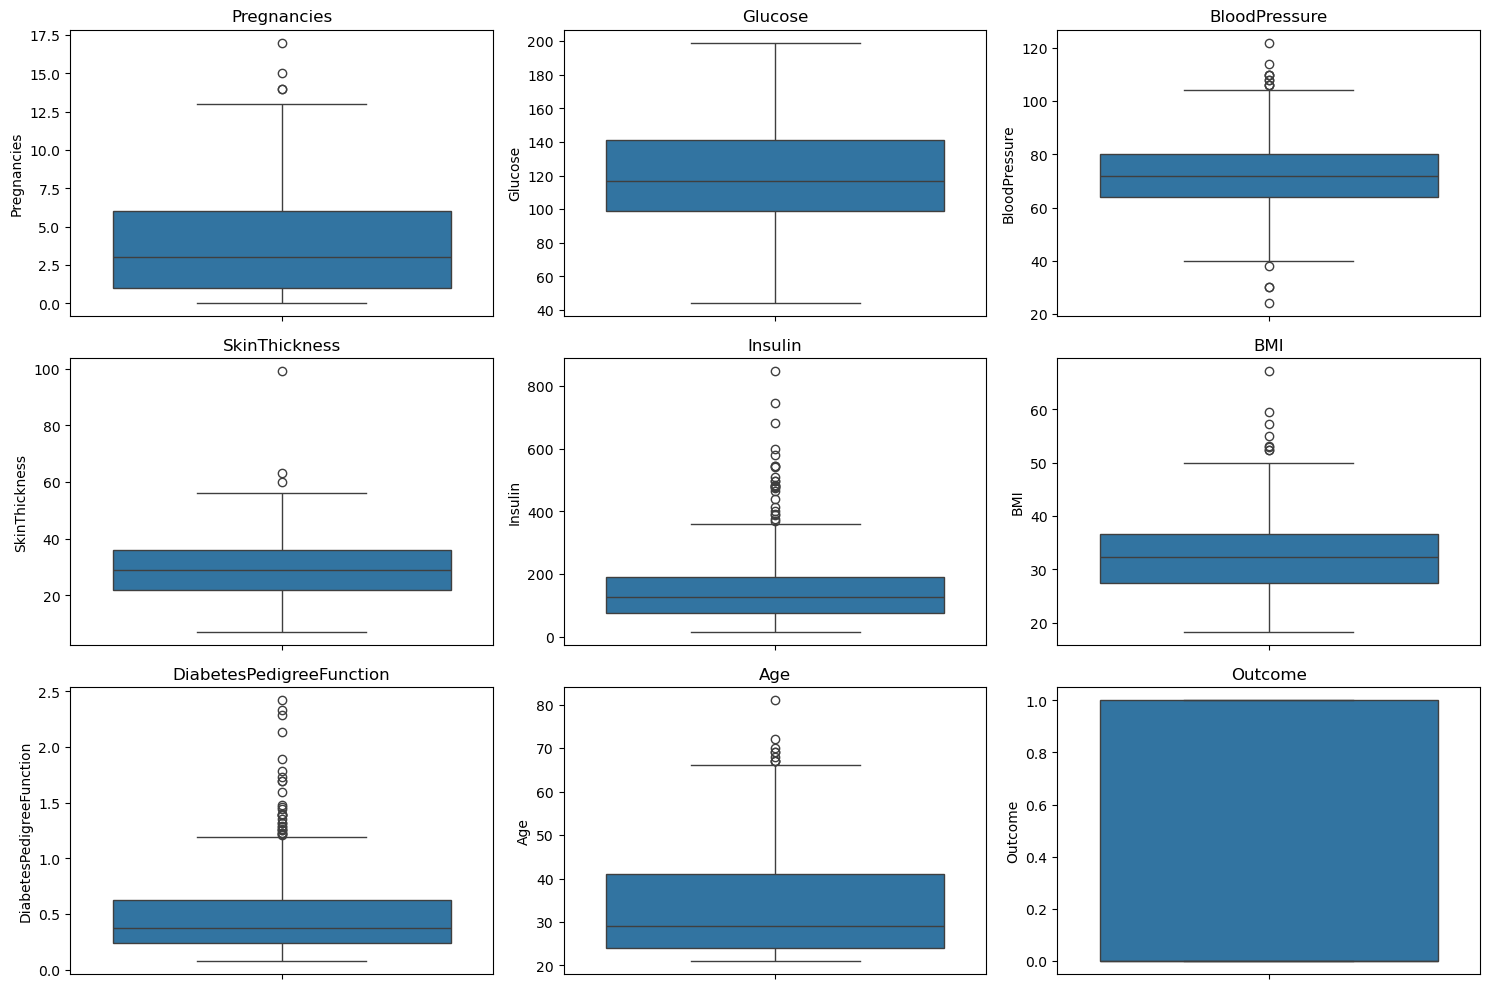

In [494]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()



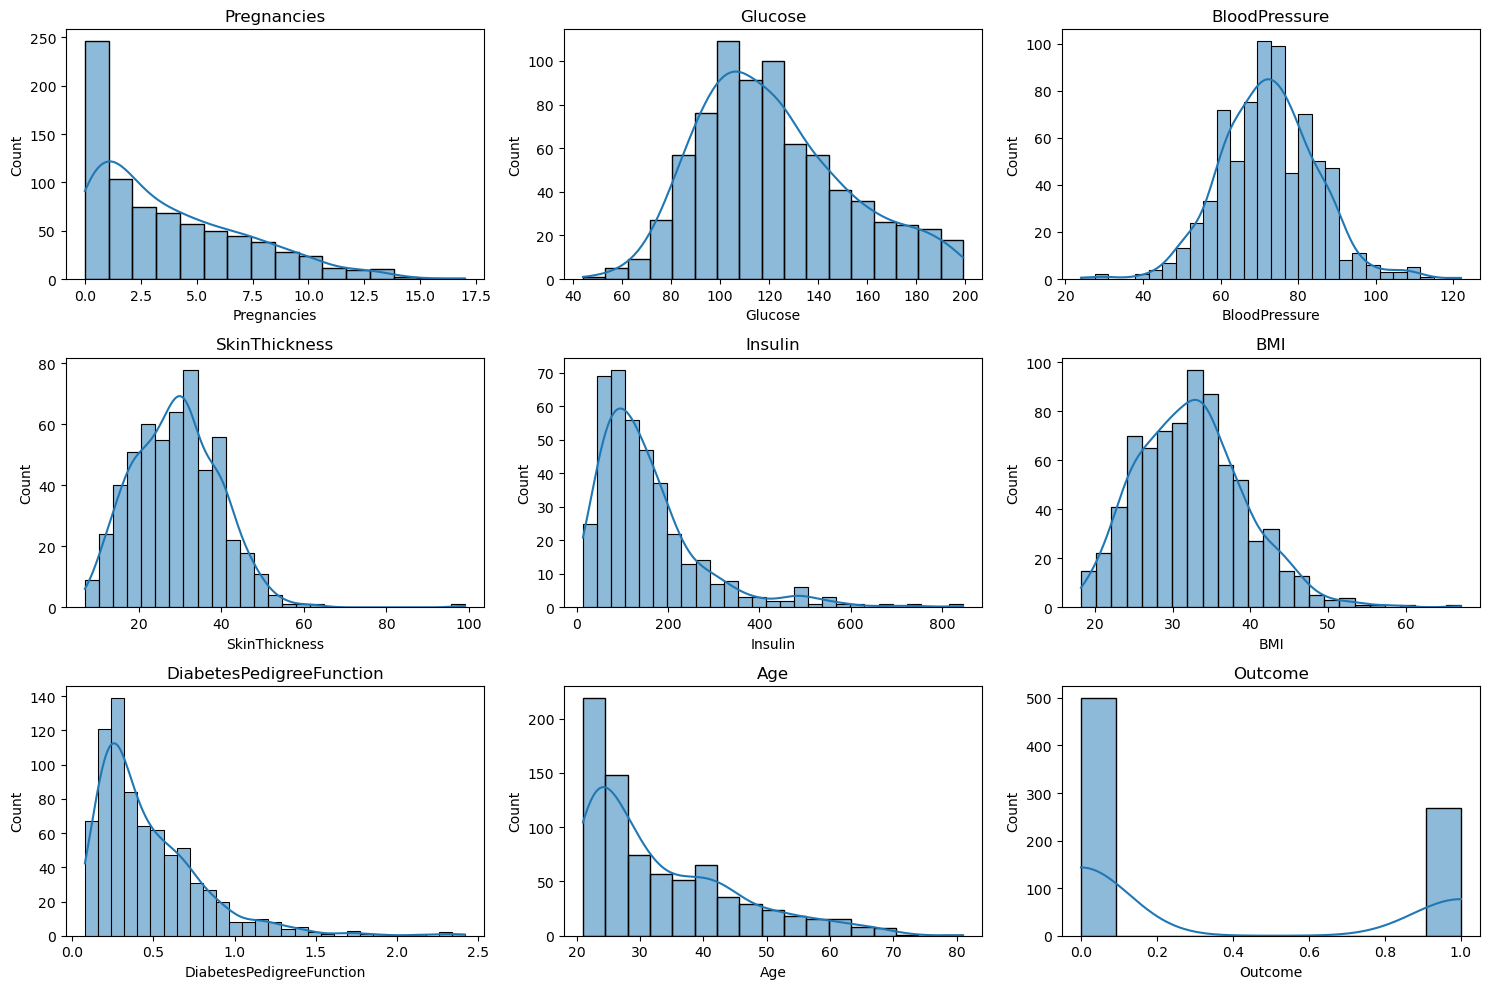

In [495]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)
    sns.histplot(x=df[col],kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [496]:
# df["DPF_Category"] = pd.qcut(
#     df["DiabetesPedigreeFunction"],
#     q=4,
#     labels=[0, 1, 2, 3]
# )

<Axes: xlabel='Outcome', ylabel='Glucose'>

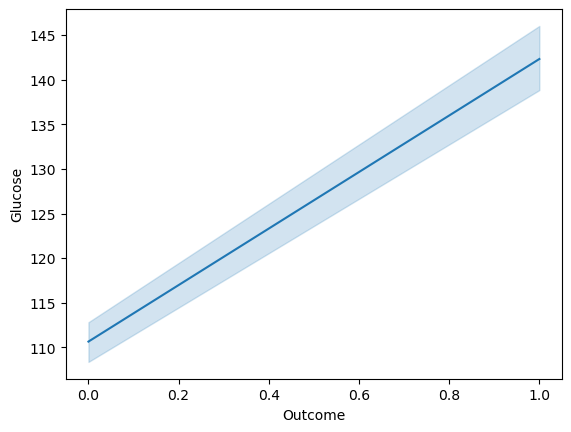

In [497]:
sns.lineplot(data=df,x="Outcome",y="Glucose")

<Axes: xlabel='Insulin', ylabel='Glucose'>

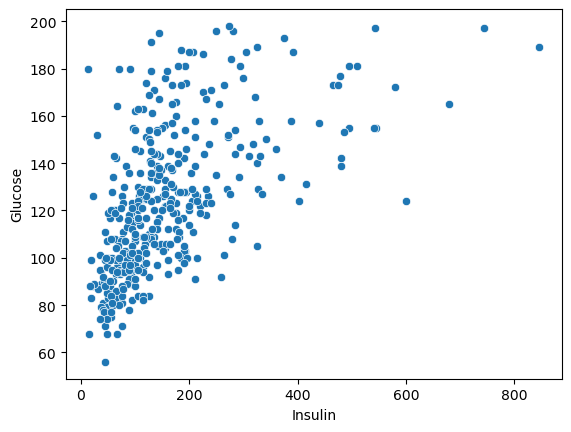

In [498]:
sns.scatterplot(data=df,x="Insulin",y="Glucose")

In [499]:
#df["bmi"]=np.where(df["BMI"]<=18.5,"Underweight",np.where(df["BMI"]<=24.9,"Normal",np.where(df["BMI"]<=29.9,"Overweight",np.where(df["BMI"]<=34.9,"Obese",np.where(df["BMI"]>=40.0,"Severe Obesity",np.where(df["BMI"]<40.1,"Very severe Obesity","Other"))))))

In [500]:
df["bmi"]=np.where(df["BMI"]<=18.5,0,np.where(df["BMI"]<=24.9,1,np.where(df["BMI"]<=29.9,2,np.where(df["BMI"]<=34.9,3,np.where(df["BMI"]>=40.0,4,np.where(df["BMI"]<40.1,5,-1))))))

In [501]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,bmi
469,6,154.00,78.00,41.00,140.00,46.10,0.57,27,0,4
636,5,104.00,74.00,NaN,NaN,28.80,0.15,48,0,2
693,7,129.00,68.00,49.00,125.00,38.50,0.44,43,1,5
608,0,152.00,82.00,39.00,272.00,41.50,0.27,27,0,4
59,0,105.00,64.00,41.00,142.00,41.50,0.17,22,0,4


In [502]:
#df["bmi"].value_counts()

In [503]:
#sns.barplot(df["bmi"])

In [504]:
#sns.countplot(x="bmi", hue="Outcome", data=df)

<Axes: xlabel='Outcome', ylabel='count'>

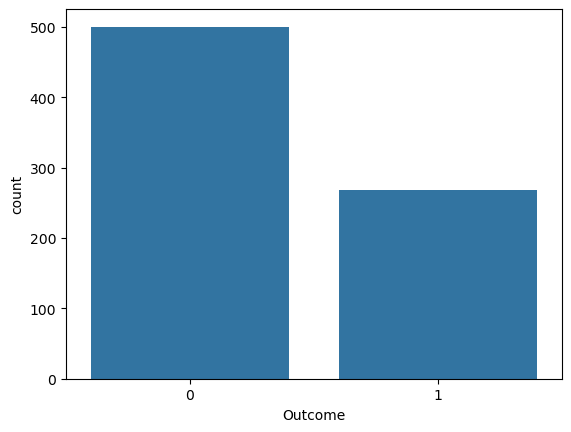

In [505]:
sns.countplot(x="Outcome", data=df)

In [506]:
df.sample(8)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,bmi
657,1,120.00,80.00,48.00,200.00,38.90,1.16,41,0,5
10,4,110.00,92.00,NaN,NaN,37.60,0.19,30,0,5
66,0,109.00,88.00,30.00,NaN,32.50,0.85,38,1,3
29,5,117.00,92.00,NaN,NaN,34.10,0.34,38,0,3
40,3,180.00,64.00,25.00,70.00,34.00,0.27,26,0,3
466,0,74.00,52.00,10.00,36.00,27.80,0.27,22,0,2
280,0,146.00,70.00,NaN,NaN,37.90,0.33,28,1,5
35,4,103.00,60.00,33.00,192.00,24.00,0.97,33,0,1


In [507]:
x = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [508]:
from sklearn.model_selection import train_test_split

xtr, xte, ytr, yte = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [509]:
# Q1 = xtr.quantile(0.25)
# Q3 = xtr.quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR
# xtr = xtr.clip(lower=lower, upper=upper, axis=1)

# xte = xte.clip(lower=lower, upper=upper, axis=1)

In [510]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

# Fit on train only
xtr = imputer.fit_transform(xtr)

# Transform test
xte = imputer.transform(xte)

# Convert back to DataFrames
xtr= pd.DataFrame(xtr, columns=x.columns)
xte = pd.DataFrame(xte, columns=x.columns)


In [511]:
num_cols = ['Age', 'bmi', 'Glucose', 'BMI',"Insulin","SkinThickness"]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtr[num_cols] = scaler.fit_transform(xtr[num_cols])
xte[num_cols] = scaler.transform(xte[num_cols])

In [512]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import cross_val_score

def ev(model, xtr, xte, ytr, yte):

    # Train the model
    model.fit(xtr, ytr)

    # Predictions
    ypr = model.predict(xte)

    # Accuracy
    accuracy = accuracy_score(yte, ypr)

    # Cross Validation
    scores = cross_val_score(
        model,
        xtr,
        ytr,
        cv=5,
        scoring="accuracy"
    )

    print(f"Cross Validation Accuracy : {scores.mean():.4f}")
    print(f"Test Accuracy             : {accuracy:.4f}")

    print("\nClassification Report")
    print(classification_report(yte, ypr))

    print("\nConfusion Matrix")
    print(confusion_matrix(yte, ypr))

In [513]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000,class_weight="balanced",)
ev(lr,xtr,xte,ytr,yte)

Cross Validation Accuracy : 0.7606
Test Accuracy             : 0.7403

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154


Confusion Matrix
[[75 25]
 [15 39]]


In [514]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

ev(rf,xtr,xte,ytr,yte)



Cross Validation Accuracy : 0.7639
Test Accuracy             : 0.7338

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       100
           1       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


Confusion Matrix
[[82 18]
 [23 31]]


In [515]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

ev(xgb, xtr, xte, ytr, yte)

Cross Validation Accuracy : 0.7541
Test Accuracy             : 0.7532

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       100
           1       0.65      0.65      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


Confusion Matrix
[[81 19]
 [19 35]]


In [516]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

mode = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    mode,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(xtr, ytr)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best Score: 0.7899373583899774


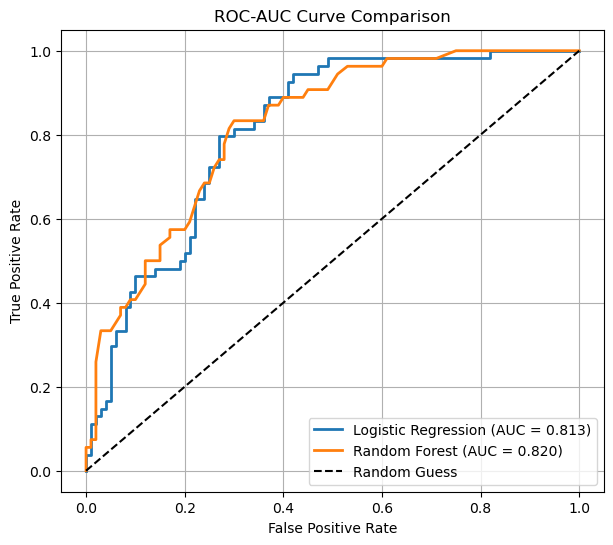

In [517]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Plot ROC Curves
plt.figure(figsize=(7,6))

for name, model in [
    ("Logistic Regression", lr),
    ("Random Forest", rf)
]:
    y_prob = model.predict_proba(xte)[:, 1]

    fpr, tpr, _ = roc_curve(yte, y_prob)
    auc_score = roc_auc_score(yte, y_prob)

    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC = {auc_score:.3f})")

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()